# Notebook to compute noise level, mask and shear map from COSMOS

In [ ]:
%config InlineBackend.figure_format = 'svg'
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import astropy as ap
import torch

import wlmmuq as wl
import wlmmuq.datasets.cosmos as wlcosmos
import wlmmuq.datasets.kappatng as wlktng

from wlmmuq import PATH_TO_ZBINS

Configuration file found in /local/home/hl285110/.config/wlmmuq


/local/home/hl285110/.venv/wlmmuq/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
imgsize = 384
max_z_ktng = 2.6
idx_zbins = [2, 4, 6, 8, 10] # Group Euclid redshift bins 2 by 2

In [3]:
vmin = -0.04
vmax = 0.29
vmax_gamma = 0.2
imgsize_imshow = 304
savedir = "~/Data/COSMOS"

In [4]:
zbins = wl.utils.get_zbins(PATH_TO_ZBINS, idx_zbins=idx_zbins)

In [ ]:
ra, dec = np.array(wlcosmos.COSMOS_VERTICES).T # Survey boundaries
cat_cosmos_bright, _ = wlcosmos.cosmos_catalog() # TODO: update (what about max_z?)
cosmos_data = wlcosmos.get_data_from_cosmos(
    cat_cosmos_bright, imgsize, wlktng.RESOLUTION,
    metadata_only=True
)
extent = cosmos_data.extent

In [6]:
savedir = os.path.expanduser(savedir)

In [ ]:
def get_stdnoise_mask_shearmap(
        cosmos_include_faint: bool = False,
        max_z: float | None = None,
        zbins: list[float] | None = None
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:

    cat_cosmos_bright, cat_cosmos_faint = wlcosmos.cosmos_catalog() # TODO: update
    if max_z is not None:
        cat_cosmos_bright = wlcosmos.filter_by_redshifts(cat_cosmos_bright, max_z) # TODO: remove
    if cosmos_include_faint:
        cat_cosmos = ap.table.vstack(
            [cat_cosmos_bright, cat_cosmos_faint], join_type='outer'
        )
    else:
        cat_cosmos = cat_cosmos_bright
    cosmos_data = wlcosmos.get_data_from_cosmos(
        cat_cosmos, imgsize=imgsize,
        resolution=wlktng.RESOLUTION,
        get_noisy_shear_map=True,
        east_right=True,
        zbins=zbins, max_z=max_z
    )
    assert cosmos_data.std_noise is not None
    assert cosmos_data.mask is not None
    assert cosmos_data.gamma is not None

    return cosmos_data.std_noise, cosmos_data.mask, cosmos_data.gamma

In [8]:
def plot_maps(std_noise, mask, gamma):

    plt.figure(figsize=(18, 4))
    plt.subplot(131)
    wl.utils.skyshow(
        std_noise[0], imgsize=imgsize_imshow,
        boundaries=(ra, dec), extent=extent,
        vmin=vmin, vmax=vmax
    )
    plt.title("Noise standard deviation per pixel")
    plt.subplot(132)
    wl.utils.skyshow(
        mask[0], imgsize=imgsize_imshow,
        boundaries=(ra, dec), extent=extent
    )
    plt.title("Mask")
    plt.subplot(133)
    wl.utils.skyshow(
        gamma.real[0], imgsize=imgsize_imshow,
        boundaries=(ra, dec), extent=extent,
        vmin=-vmax_gamma, vmax=vmax_gamma, cmap="coolwarm"
    )
    plt.title("Shear map (real part)")
    plt.show()

In [9]:
def save_tensors(std_noise, mask, gamma, filename_compl=None):
    if filename_compl is None:
        filename_compl = f"{imgsize}"
    else:
        filename_compl = f"{filename_compl}_{imgsize}"
    torch.save(std_noise, os.path.join(savedir, f"std_noise_{filename_compl}.pt"))
    torch.save(mask, os.path.join(savedir, f"mask_{filename_compl}.pt"))
    torch.save(gamma, os.path.join(savedir, f"shearmap_{filename_compl}.pt"))

#### One redshift bin

Bright catalog only

In [10]:
# All redshifts
std_noise, mask, gamma = get_stdnoise_mask_shearmap()

# Filter out redshifts above 2.6 (as in kappaTNG)
std_noise_filt, mask_filt, gamma_filt = get_stdnoise_mask_shearmap(
    max_z=max_z_ktng
)

/local/home/hl285110/Documents/Code/weaklensing/wlmmuq/datasets/cosmos.py:154: RuntimeWarning: invalid value encountered in divide
  shapedisp * l2norm_nhweight_int / sum_nhweight_int,
/local/home/hl285110/Documents/Code/weaklensing/wlmmuq/datasets/cosmos.py:154: RuntimeWarning: invalid value encountered in divide
  shapedisp * l2norm_nhweight_int / sum_nhweight_int,


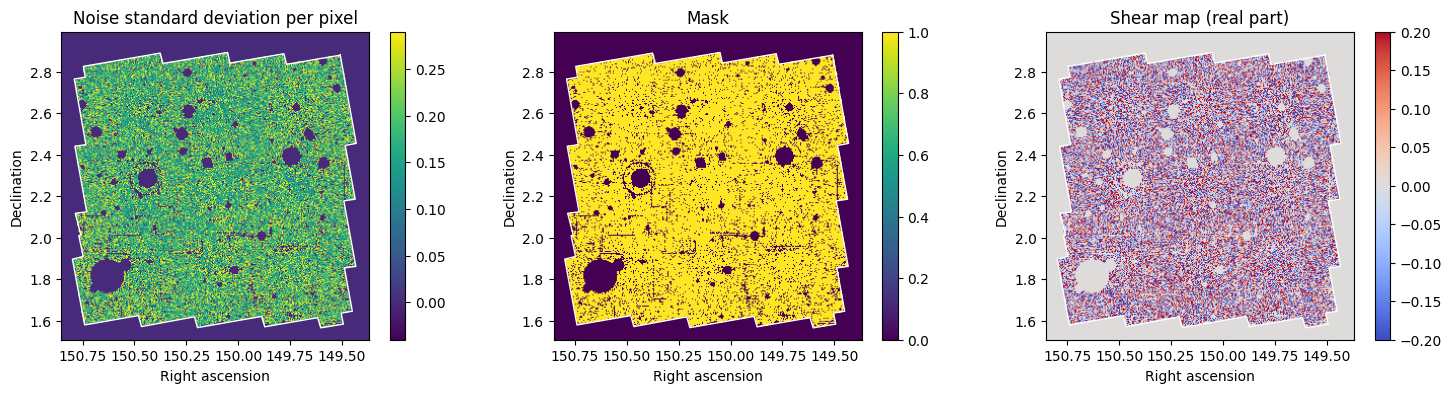

In [11]:
plot_maps(std_noise, mask, gamma)
save_tensors(std_noise, mask, gamma)
save_tensors(std_noise_filt, mask_filt, gamma_filt, filename_compl="filt")

Bright + faint catalogs

In [12]:
# All redshifts
std_noise_bf, mask_bf, gamma_bf = get_stdnoise_mask_shearmap(
    cosmos_include_faint=True
)

# Filter out redshifts above 2.6 (as in kappaTNG)
std_noise_bf_filt, mask_bf_filt, gamma_bf_filt = get_stdnoise_mask_shearmap(
    cosmos_include_faint=True, max_z=max_z_ktng
)

/local/home/hl285110/Documents/Code/weaklensing/wlmmuq/datasets/cosmos.py:154: RuntimeWarning: invalid value encountered in divide
  shapedisp * l2norm_nhweight_int / sum_nhweight_int,
/local/home/hl285110/Documents/Code/weaklensing/wlmmuq/datasets/cosmos.py:154: RuntimeWarning: invalid value encountered in divide
  shapedisp * l2norm_nhweight_int / sum_nhweight_int,


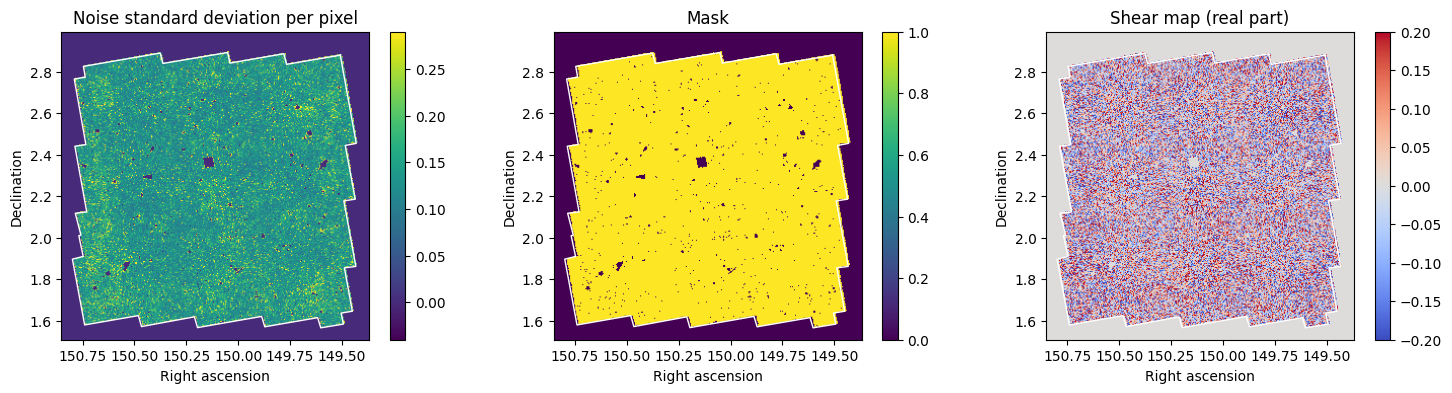

In [13]:
plot_maps(std_noise_bf, mask_bf, gamma_bf)
save_tensors(std_noise_bf, mask_bf, gamma_bf, filename_compl="bf")
save_tensors(std_noise_bf_filt, mask_bf_filt, gamma_bf_filt, filename_compl="bf_filt")

#### Several redshift bins

Bright catalog only

In [14]:
# All redshifts
std_noise_zbins, mask_zbins, gamma_zbins = get_stdnoise_mask_shearmap(
    zbins=zbins
)

# Filter out redshifts above 2.6 (as in kappaTNG)
std_noise_filt_zbins, mask_filt_zbins, gamma_filt_zbins = get_stdnoise_mask_shearmap(
    max_z=max_z_ktng, zbins=zbins
)

/local/home/hl285110/Documents/Code/weaklensing/wlmmuq/datasets/cosmos.py:154: RuntimeWarning: invalid value encountered in divide
  shapedisp * l2norm_nhweight_int / sum_nhweight_int,
/local/home/hl285110/Documents/Code/weaklensing/wlmmuq/datasets/cosmos.py:154: RuntimeWarning: invalid value encountered in divide
  shapedisp * l2norm_nhweight_int / sum_nhweight_int,


In [15]:
save_tensors(std_noise_zbins, mask_zbins, gamma_zbins, filename_compl="zbins")
save_tensors(std_noise_filt_zbins, mask_filt_zbins, gamma_filt_zbins, filename_compl="filt_zbins")

Bright + faint catalogs

In [16]:
# All redshifts
std_noise_bf_zbins, mask_bf_zbins, gamma_bf_zbins = get_stdnoise_mask_shearmap(
    cosmos_include_faint=True, zbins=zbins
)

# Filter out redshifts above 2.6 (as in kappaTNG)
std_noise_bf_filt_zbins, mask_bf_filt_zbins, gamma_bf_filt_zbins = get_stdnoise_mask_shearmap(
    cosmos_include_faint=True, max_z=max_z_ktng, zbins=zbins
)

/local/home/hl285110/Documents/Code/weaklensing/wlmmuq/datasets/cosmos.py:154: RuntimeWarning: invalid value encountered in divide
  shapedisp * l2norm_nhweight_int / sum_nhweight_int,
/local/home/hl285110/Documents/Code/weaklensing/wlmmuq/datasets/cosmos.py:154: RuntimeWarning: invalid value encountered in divide
  shapedisp * l2norm_nhweight_int / sum_nhweight_int,


In [17]:
save_tensors(std_noise_bf_zbins, mask_bf_zbins, gamma_bf_zbins, filename_compl="bf_zbins")
save_tensors(std_noise_bf_filt_zbins, mask_bf_filt_zbins, gamma_bf_filt_zbins, filename_compl="bf_filt_zbins")